In [1]:
import pandas as pd

df = pd.read_csv("../data/dataset_final.csv")
print(df.shape)
df.head()

(305, 18)


,Machine_ID,Machine_Name,Platform,Platform_ID,OS,OS_Detail,Difficulty,Difficulty_Numeric,Attack_Category,Attack_Category_Detail,Vulnerability_Type,Kill_Chain_Stages,Skills_Required,Learning_Objectives,Estimated_Time,Estimated_Time_Hours,Attack_Path_Length,Entry_Point
0,1,LAMPSecurity CTF 4,VulnHub,0,Linux,NaN,Easy,1,Web Exploitation,Web Exploitation,SQL Injection → Credential Extraction → Privil...,Recon → Exploitation → Credential Access → Pri...,Enumeration; Exploitation; Credential Extracti...,SQL Injection; Credential Extraction; Privileg...,<1 hour,0.5,5,SQL Injection (login/input parameter)
1,2,LAMPSecurity CTF 5,VulnHub,0,Linux,NaN,Easy,1,Web Exploitation,Web Exploitation,Local File Inclusion (LFI) → Credential Extrac...,Recon → Exploitation → Credential Access → Pri...,Enumeration; Exploitation; Credential Extracti...,Local File Inclusion; Credential Extraction; P...,1-2 hours,1.5,6,Local File Inclusion (web parameter)
2,3,LAMPSecurity CTF 7,VulnHub,0,Linux,NaN,Easy,1,Web Exploitation,Web Exploitation,SQL Injection → File Upload → Credential Extra...,Recon → Exploitation → Credential Access → Pri...,Enumeration; Exploitation; Credential Extracti...,SQL Injection; File Upload Exploitation; Crede...,1-2 hours,1.5,7,SQL Injection (authentication bypass)
3,4,HolyNix 1,VulnHub,0,Linux,NaN,Medium,2,Web Exploitation,Web Exploitation,SQL Injection → File Inclusion → Credential Ex...,Recon → Exploitation → Credential Access → Pri...,Enumeration; Exploitation; Credential Extracti...,SQL Injection; Local File Inclusion; Credentia...,2-3 hours,2.5,8,SQL Injection (web form)
4,5,pWnOS 1.0,VulnHub,0,Linux,NaN,Medium,2,Web Exploitation,Web Exploitation,Arbitrary File Disclosure → Credential Extract...,Recon → Exploitation → Credential Access → Pri...,Enumeration; Exploitation; Credential Extracti...,File Disclosure; Credential Extraction; Privil...,2-3 hours,2.5,7,Arbitrary File Disclosure (web endpoint)


In [2]:
#Checking for missing values
df.isnull().sum()

Machine_ID                 0
Machine_Name               0
Platform                   0
Platform_ID                0
OS                         0
OS_Detail                 67
Difficulty                 0
Difficulty_Numeric         0
Attack_Category            0
Attack_Category_Detail     0
Vulnerability_Type         0
Kill_Chain_Stages          0
Skills_Required            0
Learning_Objectives        0
Estimated_Time             0
Estimated_Time_Hours       0
Attack_Path_Length         0
Entry_Point                0
dtype: int64

In [3]:
#Fill missing OS_Detail values with empty string
df['OS_Detail'] = df['OS_Detail'].fillna('')
#Verify no missing value remains
df.isnull().sum()

Machine_ID                0
Machine_Name              0
Platform                  0
Platform_ID               0
OS                        0
OS_Detail                 0
Difficulty                0
Difficulty_Numeric        0
Attack_Category           0
Attack_Category_Detail    0
Vulnerability_Type        0
Kill_Chain_Stages         0
Skills_Required           0
Learning_Objectives       0
Estimated_Time            0
Estimated_Time_Hours      0
Attack_Path_Length        0
Entry_Point               0
dtype: int64

In [4]:
# Check basic statistics of numeric columns
# This helps us verify the values are in expected ranges
# Attack_Path_Length should be between 3-14
# Estimated_Time_Hours should be between 0.5-6
# Difficulty_Numeric should be 1, 2, or 3 only

df[['Attack_Path_Length', 'Estimated_Time_Hours', 
    'Difficulty_Numeric', 'Platform_ID']].describe()

,Attack_Path_Length,Estimated_Time_Hours,Difficulty_Numeric,Platform_ID
count,305.000000,305.000000,305.000000,305.000000
mean,9.311475,2.813934,2.216393,0.003279
std,1.937689,0.868876,0.658242,0.057260
min,3.000000,0.500000,1.000000,0.000000
25%,8.000000,2.500000,2.000000,0.000000
50%,9.000000,2.500000,2.000000,0.000000
75%,11.000000,3.500000,3.000000,0.000000
max,14.000000,5.500000,3.000000,1.000000


In [5]:
# Check how many machines are Easy, Medium and Hard

# If one class has very few machines, model may struggle to learn it

print("Difficulty distribution:")
print(df['Difficulty'].value_counts())
print()
print("As percentage:")
print(df['Difficulty'].value_counts(normalize=True).round(2) * 100)

Difficulty distribution:
Difficulty
Medium    159
Hard      106
Easy       40
Name: count, dtype: int64

As percentage:
Difficulty
Medium    52.0
Hard      35.0
Easy      13.0
Name: proportion, dtype: float64


In [6]:
# Check distribution of attack categories
# We want to see if all 6 categories are well represented
# This affects how well our recommender can match student preferences

print("Attack Category distribution:")
print(df['Attack_Category'].value_counts())

Attack Category distribution:
Attack_Category
Web Exploitation                 264
Network Exploitation              28
Mixed (Web + Network)              5
Binary Exploitation                3
Credential-Based Exploitation      3
Cryptographic Exploitation         2
Name: count, dtype: int64


In [7]:
# Check unique token counts for multi-value columns
# This tells us how large our feature matrix will be after encoding
# More unique tokens = more columns in X

print("Skills_Required unique tokens:")
from collections import Counter
import re

skills_tokens = []
for s in df['Skills_Required'].dropna():
    for sk in s.split(';'):
        skills_tokens.append(sk.strip())
print(f"  Total unique skills: {len(set(skills_tokens))}")

print("\nLearning_Objectives unique tokens:")
lo_tokens = []
for s in df['Learning_Objectives'].dropna():
    for lo in s.split(';'):
        lo_tokens.append(lo.strip())
print(f"  Total unique objectives: {len(set(lo_tokens))}")

print("\nKill_Chain_Stages unique tokens:")
kc_tokens = []
for s in df['Kill_Chain_Stages'].dropna():
    for kc in s.split('→'):
        kc_tokens.append(kc.strip())
print(f"  Total unique stages: {len(set(kc_tokens))}")

Skills_Required unique tokens:
  Total unique skills: 196

Learning_Objectives unique tokens:
  Total unique objectives: 197

Kill_Chain_Stages unique tokens:
  Total unique stages: 9


In [8]:
# Reset Machine_ID to be clean and continuous (1, 2, 3, ...)


df = df.reset_index(drop=True)
df['Machine_ID'] = df.index + 1

# Verify
print(f"Machine_ID range: {df['Machine_ID'].min()} to {df['Machine_ID'].max()}")
print(f"Total machines: {len(df)}")

Machine_ID range: 1 to 305
Total machines: 305


In [9]:
# IMPROVED IMPLICIT DIFFICULTY SCORE ────
#  combine effort + breadth + depth signals
# Complexity signals have different weights because:
#   Binary/ROP = deepest technical knowledge (0.35)
#   Crypto/Steg = problem solving depth (0.25)
#   Pivoting = multi-host thinking (0.25)
#   Multi-service = more attack surface (0.15)

# Count number of skills per machine
df['skills_count'] = df['Skills_Required'].fillna('').apply(
    lambda x: len([s for s in x.split(';') if s.strip()])
)

# Count number of kill chain stages per machine
df['stages_count'] = df['Kill_Chain_Stages'].fillna('').apply(
    lambda x: len([s for s in x.split('→') if s.strip()])
)

# Complexity signals using lowercase for safer matching
df['has_binary'] = df['Skills_Required'].str.lower().str.contains(
    'binary|rop|buffer overflow|exploit development', na=False
).astype(int)

df['has_crypto'] = df['Skills_Required'].str.lower().str.contains(
    'crypto|encoding|steganography|padding oracle', na=False
).astype(int)

df['has_pivot'] = df['Skills_Required'].str.lower().str.contains(
    'pivot|lateral|port forward|proxychains', na=False
).astype(int)

df['has_multi_service'] = df['Entry_Point'].str.lower().str.contains(
    'ftp|smb|nfs|snmp|irc', na=False
).astype(int)

# Weighted complexity score
# Binary weighted highest because it requires deepest technical knowledge
complexity_score = (
    0.35 * df['has_binary'] +
    0.25 * df['has_crypto'] +
    0.25 * df['has_pivot'] +
    0.15 * df['has_multi_service']
)

# Normalize count-based features to 0-1 range
from sklearn.preprocessing import MinMaxScaler
scaler_temp = MinMaxScaler()
df[['path_norm', 'skills_norm', 'stages_norm']] = scaler_temp.fit_transform(
    df[['Attack_Path_Length', 'skills_count', 'stages_count']]
)

# Final implicit difficulty score
df['implicit_difficulty'] = (
    0.3 * df['path_norm'] +        # effort
    0.3 * df['skills_norm'] +      # breadth
    0.1 * df['stages_norm'] +      # structure
    0.3 * complexity_score         # depth
)

# Sanity check — Hard should score higher than Easy
print("Average implicit difficulty by label:")
print(df.groupby('Difficulty')['implicit_difficulty'].mean().sort_values(ascending=False))
print()
print("Implicit difficulty stats:")
print(df['implicit_difficulty'].describe())

Average implicit difficulty by label:
Difficulty
Hard      0.535752
Medium    0.348863
Easy      0.152885
Name: implicit_difficulty, dtype: float64

Implicit difficulty stats:
count    305.000000
mean       0.388112
std        0.160843
min        0.021429
25%        0.251494
50%        0.448636
75%        0.492468
max        0.787857
Name: implicit_difficulty, dtype: float64


In [10]:
# ── ENCODING: Skills_Required (Multi-Value Column) ───────────────────────────
# Multi-Label Binarization.

from sklearn.preprocessing import MultiLabelBinarizer

# Initialize the encoder
mlb_skills = MultiLabelBinarizer()

# Step 1 — Convert each row into a list of skills
# - Handle missing values using fillna('')
# - Split on ';'
# - Strip whitespace
# - Remove empty values
skills_split = df['Skills_Required'].fillna('').apply(
    lambda x: [s.strip() for s in x.split(';') if s.strip()]
)

# Step 2 — Apply MultiLabelBinarizer
# This creates a binary matrix:
# rows = machines
# columns = unique skills
skills_encoded = pd.DataFrame(
    mlb_skills.fit_transform(skills_split),

    # Prefix each column with 'skill__' for clarity and consistency
    columns=[f"skill__{c}" for c in mlb_skills.classes_],

    # Keep index aligned with original dataframe (IMPORTANT for merging later)
    index=df.index
)

# Step 3 — Inspect results
print(f"Skills encoded shape: {skills_encoded.shape}")
print(f"Sample skill columns: {list(skills_encoded.columns[:5])}")
print(f"Total unique skills: {len(mlb_skills.classes_)}")

Skills encoded shape: (305, 196)
Sample skill columns: ['skill__ADB Access', 'skill__API Enumeration', 'skill__Admin Access', 'skill__Application Access', 'skill__Application Discovery']
Total unique skills: 196


In [11]:
# Encode Learning_Objectives
# Same approach as Skills_Required — split on ; and binarize
mlb_objectives = MultiLabelBinarizer()
objectives_split = df['Learning_Objectives'].fillna('').apply(
    lambda x: [s.strip() for s in x.split(';') if s.strip()]
)
objectives_encoded = pd.DataFrame(
    mlb_objectives.fit_transform(objectives_split),
    columns=[f"obj__{c}" for c in mlb_objectives.classes_],
    index=df.index
)

print(f"Objectives encoded shape: {objectives_encoded.shape}")
print(f"Total unique objectives: {len(mlb_objectives.classes_)}")

Objectives encoded shape: (305, 197)
Total unique objectives: 197


In [12]:
# Encode Kill_Chain_Stages
# Split on → instead of ;
mlb_killchain = MultiLabelBinarizer()
killchain_split = df['Kill_Chain_Stages'].fillna('').apply(
    lambda x: [s.strip() for s in x.split('→') if s.strip()]
)
killchain_encoded = pd.DataFrame(
    mlb_killchain.fit_transform(killchain_split),
    columns=[f"stage__{c}" for c in mlb_killchain.classes_],
    index=df.index
)

print(f"Kill chain encoded shape: {killchain_encoded.shape}")
print(f"Total unique stages: {len(mlb_killchain.classes_)}")

Kill chain encoded shape: (305, 9)
Total unique stages: 9


In [13]:
# One-Hot encode single-value categorical columns
# Entry_Point and Vulnerability_Type included because
# students will input these as preferences in the recommender

attack_cat_encoded = pd.get_dummies(
    df['Attack_Category'].fillna('Unknown'), prefix='attack'
).astype(int)

os_encoded = pd.get_dummies(
    df['OS'].fillna('Unknown'), prefix='os'
).astype(int)

entry_encoded = pd.get_dummies(
    df['Entry_Point'].fillna('Unknown'), prefix='entry'
).astype(int)

vuln_encoded = pd.get_dummies(
    df['Vulnerability_Type'].fillna('Unknown'), prefix='vuln'
).astype(int)

print(f"Attack category encoded shape:    {attack_cat_encoded.shape}")
print(f"OS encoded shape:                 {os_encoded.shape}")
print(f"Entry point encoded shape:        {entry_encoded.shape}")
print(f"Vulnerability type encoded shape: {vuln_encoded.shape}")

Attack category encoded shape:    (305, 6)
OS encoded shape:                 (305, 3)
Entry point encoded shape:        (305, 132)
Vulnerability type encoded shape: (305, 224)


In [14]:
# Quick check on encoded columns
print(f"Sample objective columns: {list(objectives_encoded.columns[:5])}")
print()
print(f"All stage columns: {list(killchain_encoded.columns)}")

Sample objective columns: ['obj__API Endpoint Discovery', 'obj__API Enumeration', 'obj__Access Control Bypass', 'obj__Admin Panel Access', 'obj__Alternative Access Paths (ADB)']

All stage columns: ['stage__Collection', 'stage__Credential Access', 'stage__Data Exfiltration', 'stage__Execution', 'stage__Exploitation', 'stage__Initial Access', 'stage__Lateral Movement', 'stage__Privilege Escalation', 'stage__Recon']


In [15]:
# Scale numeric columns to 0-1 range
# So no single column dominates just because of its scale
# Difficulty_Numeric is NOT included — it is our target variable y
# Including it in X would be data leakage (giving the model the answer)

from sklearn.preprocessing import MinMaxScaler

numeric_cols = ['Attack_Path_Length', 'Estimated_Time_Hours', 
                'Platform_ID', 'implicit_difficulty']

scaler = MinMaxScaler()
numeric_scaled = pd.DataFrame(
    scaler.fit_transform(df[numeric_cols]),
    columns=numeric_cols,
    index=df.index
)

print("Numeric columns scaled to 0-1 range:")
print(numeric_scaled.describe().round(2))

Numeric columns scaled to 0-1 range:


       Attack_Path_Length  Estimated_Time_Hours  Platform_ID  \
count              305.00                305.00       305.00   
mean                 0.57                  0.46         0.00   
std                  0.18                  0.17         0.06   
min                  0.00                  0.00         0.00   
25%                  0.45                  0.40         0.00   
50%                  0.55                  0.40         0.00   
75%                  0.73                  0.60         0.00   
max                  1.00                  1.00         1.00   

       implicit_difficulty  
count               305.00  
mean                  0.48  
std                   0.21  
min                   0.00  
25%                   0.30  
50%                   0.56  
75%                   0.61  
max                   1.00  


In [16]:
# Combine all encoded features into final feature matrix X
# This is what our ML model will train on
# y is what we want to predict (Easy/Medium/Hard)

X = pd.concat([
    numeric_scaled,
    skills_encoded,
    objectives_encoded,
    killchain_encoded,
    attack_cat_encoded,
    os_encoded,
    entry_encoded,
    vuln_encoded
], axis=1)

# Target variable
y = df['Difficulty_Numeric'].values

print(f"Feature matrix X shape: {X.shape}")
print(f"Target variable y shape: {y.shape}")
print(f"Missing values in X: {X.isnull().sum().sum()}")
print()
print("Difficulty distribution in y:")
print(f"  Easy   (1): {sum(y==1)}")
print(f"  Medium (2): {sum(y==2)}")
print(f"  Hard   (3): {sum(y==3)}")

Feature matrix X shape: (305, 771)
Target variable y shape: (305,)
Missing values in X: 0

Difficulty distribution in y:
  Easy   (1): 40
  Medium (2): 159
  Hard   (3): 106


In [17]:
import joblib
import os

# Save all encoders and the feature matrix
# So we can load them later in supervised.py and recommender.py
# without repeating all the preprocessing steps

os.makedirs('../saved_models', exist_ok=True)

joblib.dump(X, '../saved_models/feature_matrix.pkl')
joblib.dump(y, '../saved_models/target_y.pkl')
joblib.dump(scaler, '../saved_models/scaler.pkl')

joblib.dump({
    'mlb_skills': mlb_skills,
    'mlb_objectives': mlb_objectives,
    'mlb_killchain': mlb_killchain,
    'attack_cat_encoded_columns': attack_cat_encoded.columns.tolist(),
    'os_encoded_columns': os_encoded.columns.tolist(),
    'entry_encoded_columns': entry_encoded.columns.tolist(),
    'vuln_encoded_columns': vuln_encoded.columns.tolist(),
    'numeric_cols': numeric_cols,
    'feature_names': X.columns.tolist()
}, '../saved_models/encoders.pkl')

# Save machine info for displaying recommendations later
machine_info = df[['Machine_ID', 'Machine_Name', 'Platform', 'OS', 
                    'Difficulty', 'Attack_Category', 'Entry_Point',
                    'Estimated_Time', 'Attack_Path_Length']].reset_index(drop=True)

joblib.dump(machine_info, '../saved_models/machine_info.pkl')

print("All files saved to saved_models/")
print(os.listdir('../saved_models'))

All files saved to saved_models/
['encoders.pkl', 'feature_matrix.pkl', 'machine_info.pkl', 'random_forest.pkl', 'scaler.pkl', 'target_y.pkl']


In [18]:
# ── PHASE 3: SUPERVISED ML MODEL ─────────────────────────────────────────────
# Load the feature matrix and target variable we saved in Phase 2

import joblib
import numpy as np

X = joblib.load('../saved_models/feature_matrix.pkl')
y = joblib.load('../saved_models/target_y.pkl')

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (305, 771)
y shape: (305,)


In [19]:
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% testing
# stratify=y ensures all difficulty classes (Easy/Medium/Hard)
# are proportionally represented in both train and test sets
# This is important because Easy only has 40 machines

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Training set:   {X_train.shape}")
print(f"Testing set:    {X_test.shape}")
print()
print("Train difficulty distribution:")
print(f"  Easy   (1): {sum(y_train==1)}")
print(f"  Medium (2): {sum(y_train==2)}")
print(f"  Hard   (3): {sum(y_train==3)}")
print()
print("Test difficulty distribution:")
print(f"  Easy   (1): {sum(y_test==1)}")
print(f"  Medium (2): {sum(y_test==2)}")
print(f"  Hard   (3): {sum(y_test==3)}")

Training set:   (244, 771)
Testing set:    (61, 771)

Train difficulty distribution:
  Easy   (1): 32
  Medium (2): 127
  Hard   (3): 85

Test difficulty distribution:
  Easy   (1): 8
  Medium (2): 32
  Hard   (3): 21


In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Train baseline models first
# So we can compare them against Random Forest later
# This shows Random Forest is the best choice

baselines = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

print("Baseline Model Results:")
print("-" * 40)

for name, model in baselines.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name:<25} Accuracy: {acc:.2%}")

Baseline Model Results:
----------------------------------------
Decision Tree             Accuracy: 96.72%
Logistic Regression       Accuracy: 85.25%
KNN                       Accuracy: 65.57%


In [21]:
# Check if Decision Tree is overfitting
# If train accuracy >> test accuracy, it memorised the data

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print(f"Decision Tree Train accuracy: {dt_model.score(X_train, y_train):.2%}")
print(f"Decision Tree Test accuracy:  {dt_model.score(X_test, y_test):.2%}")

Decision Tree Train accuracy: 99.59%
Decision Tree Test accuracy:  96.72%


In [22]:
# Test how much our engineered implicit_difficulty feature contributes
# by temporarily removing it and checking accuracy

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_no_implicit = X.drop(columns=['implicit_difficulty'])

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_no_implicit, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

dt_no_implicit = DecisionTreeClassifier(random_state=42)
dt_no_implicit.fit(X_train2, y_train2)

print(f"Accuracy WITH implicit_difficulty:    {dt_model.score(X_test, y_test):.2%}")
print(f"Accuracy WITHOUT implicit_difficulty: {dt_no_implicit.score(X_test2, y_test2):.2%}")

Accuracy WITH implicit_difficulty:    96.72%
Accuracy WITHOUT implicit_difficulty: 96.72%


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train Random Forest
# class_weight='balanced' handles class imbalance
# Easy only has 40 machines so we need this
# n_estimators=100 means 100 trees

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Check train vs test accuracy to detect overfitting
print(f"Random Forest Train accuracy: {rf_model.score(X_train, y_train):.2%}")
print(f"Random Forest Test accuracy:  {accuracy_score(y_test, y_pred_rf):.2%}")

Random Forest Train accuracy: 99.59%
Random Forest Test accuracy:  90.16%


In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Classification report shows precision, recall and F1 for each difficulty level
# This is more informative than accuracy alone
# Precision = of all machines predicted as Hard, how many were actually Hard
# Recall = of all actual Hard machines, how many did we correctly identify
# F1 = balance between precision and recall

print("Classification Report:")
print(classification_report(y_test, y_pred_rf, 
                            target_names=['Easy', 'Medium', 'Hard']))

Classification Report:
              precision    recall  f1-score   support

        Easy       0.80      1.00      0.89         8
      Medium       0.93      0.88      0.90        32
        Hard       0.90      0.90      0.90        21

    accuracy                           0.90        61
   macro avg       0.88      0.93      0.90        61
weighted avg       0.91      0.90      0.90        61



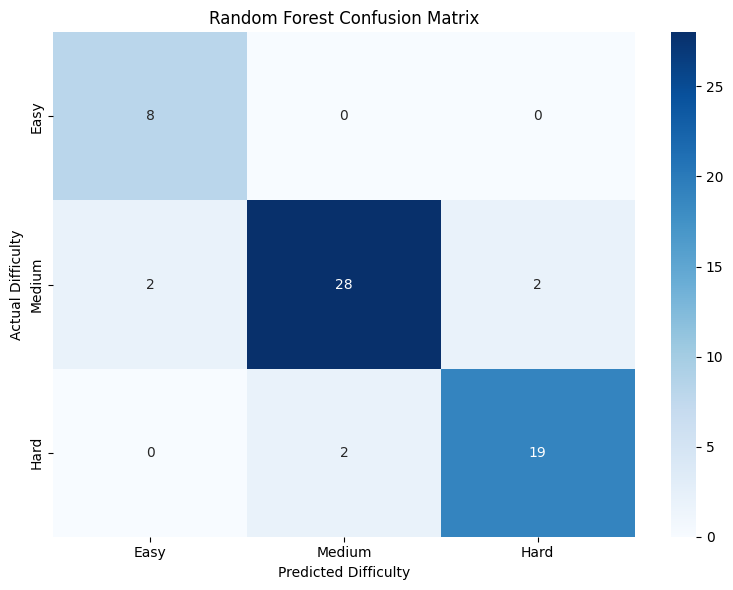

In [25]:
# Confusion matrix shows exactly which difficulty levels
# the model is confusing with each other

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Easy', 'Medium', 'Hard'],
            yticklabels=['Easy', 'Medium', 'Hard'])

plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Difficulty')
plt.xlabel('Predicted Difficulty')
plt.tight_layout()
plt.show()

In [26]:
from sklearn.model_selection import cross_val_score

# Cross validation gives more reliable accuracy estimate
# than a single train/test split
# 5-fold means we split data into 5 parts
# train on 4 parts, test on 1 part, repeat 5 times
# final score = average of all 5 runs

cv_scores = cross_val_score(
    rf_model, X, y, 
    cv=5, 
    scoring='accuracy'
)

print(f"Cross-validation scores: {cv_scores.round(4)}")
print(f"Mean accuracy:  {cv_scores.mean():.2%}")
print(f"Std deviation:  {cv_scores.std():.2%}")
print()
print(f"True model performance is approximately {cv_scores.mean():.2%} ± {cv_scores.std():.2%}")
print("Variation across folds suggests sensitivity to small dataset size")

Cross-validation scores: [0.7377 0.7869 0.9016 0.8852 0.8689]
Mean accuracy:  83.61%
Std deviation:  6.31%

True model performance is approximately 83.61% ± 6.31%
Variation across folds suggests sensitivity to small dataset size


In [27]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning using GridSearchCV
# Tries different combinations and finds the best settings
# cv=5 means 5-fold cross validation for each combination
# n_jobs=-1 uses all CPU cores to speed it up

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:  ", f"{grid_search.best_score_:.2%}")

Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV score:   91.41%


In [28]:
# Train final Random Forest with best parameters found by GridSearchCV
# Final model

rf_best = grid_search.best_estimator_

y_pred_best = rf_best.predict(X_test)

print(f"Best RF Train accuracy: {rf_best.score(X_train, y_train):.2%}")
print(f"Best RF Test accuracy:  {rf_best.score(X_test, y_test):.2%}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_best,
                            target_names=['Easy', 'Medium', 'Hard']))

Best RF Train accuracy: 98.77%
Best RF Test accuracy:  90.16%

Classification Report:
              precision    recall  f1-score   support

        Easy       0.73      1.00      0.84         8
      Medium       0.96      0.84      0.90        32
        Hard       0.91      0.95      0.93        21

    accuracy                           0.90        61
   macro avg       0.87      0.93      0.89        61
weighted avg       0.91      0.90      0.90        61



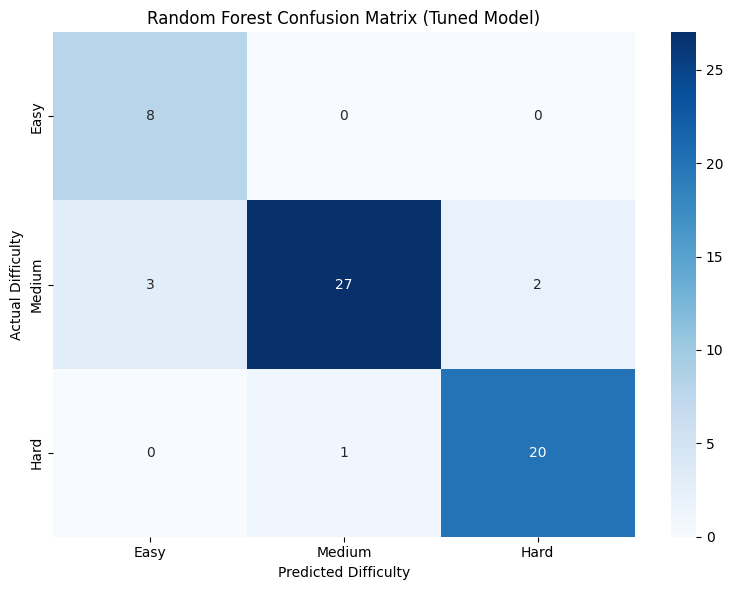

In [29]:
# Confusion matrix for the tuned model (rf_best)
# Replacing the earlier one which used the untuned model

cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_best,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Easy', 'Medium', 'Hard'],
            yticklabels=['Easy', 'Medium', 'Hard'])

plt.title('Random Forest Confusion Matrix (Tuned Model)')
plt.ylabel('Actual Difficulty')
plt.xlabel('Predicted Difficulty')
plt.tight_layout()
plt.show()

In [30]:
# Predict difficulty for ALL 305 machines
# Compare with original labels
# This shows where model agrees and disagrees with dataset labels

y_pred_all = rf_best.predict(X)

df['Predicted_Difficulty'] = y_pred_all
df['Predicted_Label'] = df['Predicted_Difficulty'].map({1:'Easy', 2:'Medium', 3:'Hard'})

# Show agreements and disagreements
df['Match'] = df['Difficulty'] == df['Predicted_Label']

print(f"Total machines: {len(df)}")
print(f"Model agrees with label:    {df['Match'].sum()} ({df['Match'].mean():.1%})")
print(f"Model disagrees with label: {(~df['Match']).sum()} ({(~df['Match']).mean():.1%})")
print()
print("Machines where model disagrees with original label:")
print(df[~df['Match']][['Machine_Name', 'Difficulty', 'Predicted_Label', 'implicit_difficulty']].to_string())

Total machines: 305
Model agrees with label:    296 (97.0%)
Model disagrees with label: 9 (3.0%)

Machines where model disagrees with original label:
        Machine_Name Difficulty Predicted_Label  implicit_difficulty
4          pWnOS 1.0     Medium            Easy             0.150519
5          pWnOS 2.0     Medium            Easy             0.150519
13        Kioptrix 5     Medium            Easy             0.136364
65   GrimTheRipper 1     Medium            Easy             0.191948
79     De-ICE S1.140       Hard          Medium             0.485909
89       FristiLeaks     Medium            Hard             0.491494
95          Fortress     Medium            Hard             0.471039
123       RootThis 1     Medium            Hard             0.471039
173  Game of Thrones       Hard          Medium             0.475909


In [31]:
import joblib

# Save the best model for use in the recommender later
joblib.dump(rf_best, '../saved_models/random_forest.pkl')
print("Best Random Forest model saved")

Best Random Forest model saved


In [32]:
# Feature importance shows which features the model found
# most useful for predicting difficulty

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 most important features:")
print(feature_importance.head(20).to_string(index=False))

Top 20 most important features:
                     feature  importance
        Estimated_Time_Hours    0.161588
          Attack_Path_Length    0.112472
         implicit_difficulty    0.094372
 skill__Directory Bruteforce    0.025335
           stage__Collection    0.023914
          obj__Reverse Shell    0.023637
            stage__Execution    0.018480
        skill__Reverse Shell    0.017631
    skill__Command Execution    0.013467
  obj__Credential Extraction    0.010401
      obj__Sudo Exploitation    0.009817
             obj__SSH Access    0.009458
skill__Credential Extraction    0.009032
       stage__Initial Access    0.008970
        skill__File Analysis    0.008693
          obj__File Analysis    0.008334
   skill__System Enumeration    0.008239
    stage__Credential Access    0.008179
         stage__Exploitation    0.008163
     obj__System Enumeration    0.008012


C:\Users\Mouri\AppData\Local\Temp\ipykernel_36188\1351286129.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


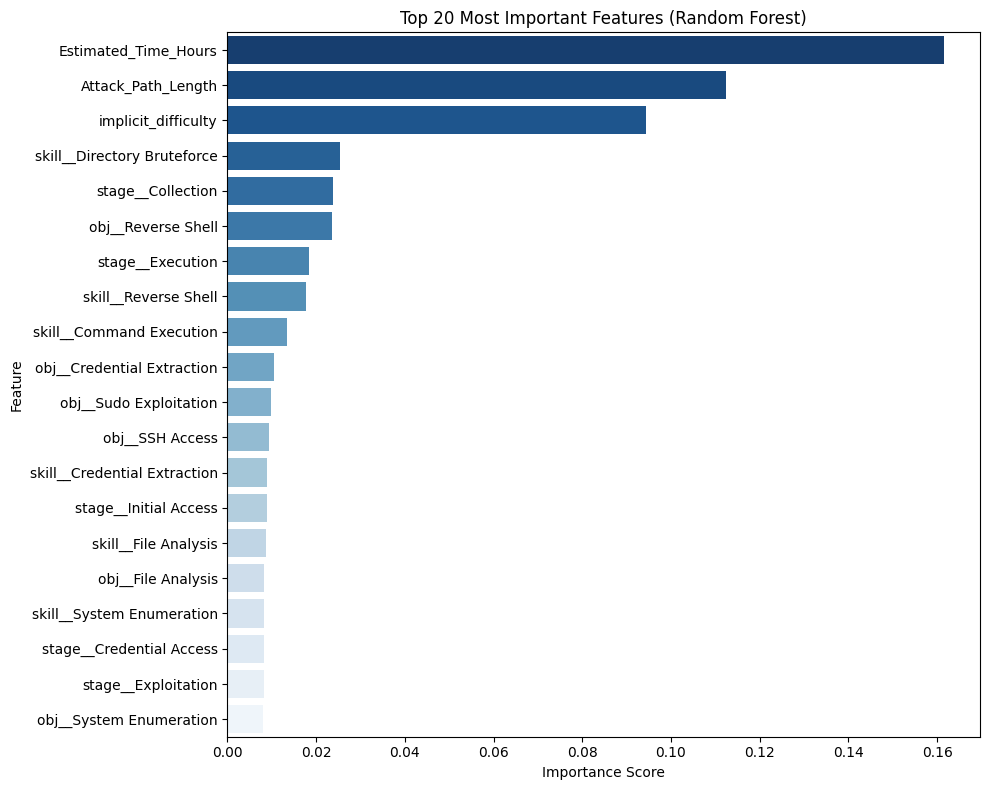

In [33]:
# Plot top 20 feature importance as a bar chart
# Visual representation is clearer than numbers alone

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(20),
    x='importance',
    y='feature',
    palette='Blues_r'
)

plt.title('Top 20 Most Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [34]:
# Predict difficulty for ALL 305 machines
# Compare with original labels
# Shows where model agrees and disagrees

y_pred_all = rf_best.predict(X)

df['Predicted_Difficulty'] = y_pred_all
df['Predicted_Label'] = df['Predicted_Difficulty'].map({1:'Easy', 2:'Medium', 3:'Hard'})

df['Match'] = df['Difficulty'] == df['Predicted_Label']

print(f"Total machines: {len(df)}")
print(f"Model agrees with label:    {df['Match'].sum()} ({df['Match'].mean():.1%})")
print(f"Model disagrees with label: {(~df['Match']).sum()} ({(~df['Match']).mean():.1%})")
print()
print("Machines where model disagrees with original label:")
print(df[~df['Match']][['Machine_Name', 'Difficulty', 
                          'Predicted_Label', 
                          'implicit_difficulty']].to_string())

Total machines: 305
Model agrees with label:    296 (97.0%)
Model disagrees with label: 9 (3.0%)

Machines where model disagrees with original label:
        Machine_Name Difficulty Predicted_Label  implicit_difficulty
4          pWnOS 1.0     Medium            Easy             0.150519
5          pWnOS 2.0     Medium            Easy             0.150519
13        Kioptrix 5     Medium            Easy             0.136364
65   GrimTheRipper 1     Medium            Easy             0.191948
79     De-ICE S1.140       Hard          Medium             0.485909
89       FristiLeaks     Medium            Hard             0.491494
95          Fortress     Medium            Hard             0.471039
123       RootThis 1     Medium            Hard             0.471039
173  Game of Thrones       Hard          Medium             0.475909


In [35]:
# ── PHASE 4: KNN RECOMMENDATION ENGINE ──
# Loaded everything  saved in Phase 2 and Phase 3

import joblib
import numpy as np
import pandas as pd

X = joblib.load('../saved_models/feature_matrix.pkl')
y = joblib.load('../saved_models/target_y.pkl')
encoders = joblib.load('../saved_models/encoders.pkl')
scaler = joblib.load('../saved_models/scaler.pkl')
machine_info = joblib.load('../saved_models/machine_info.pkl')
rf_best = joblib.load('../saved_models/random_forest.pkl')

print(f"X shape: {X.shape}")
print(f"Machines loaded: {len(machine_info)}")
print(f"Columns in machine_info: {list(machine_info.columns)}")

X shape: (305, 771)
Machines loaded: 305
Columns in machine_info: ['Machine_ID', 'Machine_Name', 'Platform', 'OS', 'Difficulty', 'Attack_Category', 'Entry_Point', 'Estimated_Time', 'Attack_Path_Length']


In [37]:
# Converting student preferences into a feature vector
# Must be in exact same format as X (771 columns)
# So KNN can compare student input against all 305 machines

def build_student_vector(
    difficulty,           # required: 'Easy', 'Medium', 'Hard'
    attack_category,      # required: 'Web Exploitation' etc.
    os_pref,             # required: 'Linux', 'Windows', 'FreeBSD'
    vuln_type,           # required: 'SQL Injection' etc.
    learning_objectives, # required: list ['SQL Injection', 'Privilege Escalation']
    skills=None,         # optional: list ['Brute Force', 'File Upload']
    entry_point=None,    # optional: 'SQL Injection - Web Form' etc.
    platform=None        # optional: 'VulnHub', 'HackTheBox'
):
    # Start with a zero vector matching X columns
    student_vector = pd.DataFrame(
        np.zeros((1, X.shape[1])), 
        columns=X.columns
    )

    # Set difficulty numeric
    diff_map = {'Easy': 0.0, 'Medium': 0.5, 'Hard': 1.0}
    if 'implicit_difficulty' in student_vector.columns:
        student_vector['implicit_difficulty'] = diff_map.get(difficulty, 0.5)

    # Set attack category
    attack_col = f"attack_{attack_category}"
    if attack_col in student_vector.columns:
        student_vector[attack_col] = 1

    # Set OS
    os_col = f"os_{os_pref}"
    if os_col in student_vector.columns:
        student_vector[os_col] = 1

    # Set vulnerability type
    vuln_col = f"vuln__{vuln_type}"
    if vuln_col in student_vector.columns:
        student_vector[vuln_col] = 1

    # Set learning objectives
    for obj in learning_objectives:
        obj_col = f"obj__{obj}"
        if obj_col in student_vector.columns:
            student_vector[obj_col] = 1

    # Optional: skills
    if skills:
        for skill in skills:
            skill_col = f"skill__{skill}"
            if skill_col in student_vector.columns:
                student_vector[skill_col] = 1

    # Optional: entry point
    if entry_point:
        entry_col = f"entry_{entry_point}"
        if entry_col in student_vector.columns:
            student_vector[entry_col] = 1

    # Optional: platform
    if platform:
        plat_map = {'VulnHub': 0.0, 'HackTheBox': 1.0}
        if 'Platform_ID' in student_vector.columns:
            student_vector['Platform_ID'] = plat_map.get(platform, 0.0)

    return student_vector

print("Student vector builder ready")
print(f"Vector will have {X.shape[1]} features")

Student vector builder ready
Vector will have 771 features


In [ ]:
# Apply feature weights based on Random Forest feature importance
# More important features get higher weights
# This makes KNN smarter — finds machines that match on features that matter most
# Instead of treating all 771 features equally

feature_weights = pd.Series(
    rf_best.feature_importances_,
    index=X.columns
)

# Apply weights to feature matrix
X_weighted = X * feature_weights

print("Feature weighting applied")
print(f"X_weighted shape: {X_weighted.shape}")
print()
print("Top 5 weighted features:")
print(feature_weights.nlargest(5))

Feature weighting applied
X_weighted shape: (305, 771)

Top 5 weighted features:
Estimated_Time_Hours           0.161588
Attack_Path_Length             0.112472
implicit_difficulty            0.094372
skill__Directory Bruteforce    0.025335
stage__Collection              0.023914
dtype: float64


In [39]:
from sklearn.neighbors import NearestNeighbors

# Train KNN on weighted feature matrix
# Using cosine similarity — works better than euclidean for high dimensional data
# n_neighbors=10 finds 10 closest machines to student preference

knn_model = NearestNeighbors(
    n_neighbors=10,
    metric='cosine',
    algorithm='brute'
)

knn_model.fit(X_weighted)

print("KNN model trained on weighted feature matrix")
print(f"Finding 10 nearest neighbors in {X_weighted.shape[1]} dimensional space")

KNN model trained on weighted feature matrix
Finding 10 nearest neighbors in 771 dimensional space
